### Wobbly criterion
Edit the `👈` value and re-run.

true sd = 0.1,   fitted sd = 0.144  (overestimated again)


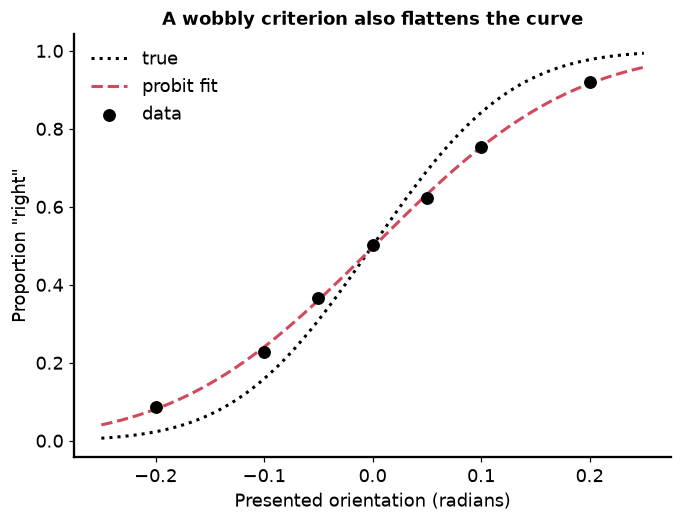

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 12, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})

def neg_log_lik(p, pf, x, n_right, n_total):
    pp = np.clip(pf(p, x), 1e-6, 1 - 1e-6)
    return -np.sum(n_right * np.log(pp) + (n_total - n_right) * np.log(1 - pp))

def probit(p, x):            # p = [mean, sd]
    return norm.cdf(x, p[0], p[1])

signal_strengths = np.array([-0.2,-0.1,-0.05,0,0.05,0.1,0.2])
noise_sd = 0.1
ntrials  = 1000
crit_wobble = 0.1     # 👈 trial-to-trial standard deviation of the criterion

rng = np.random.default_rng()
samples   = rng.standard_normal((ntrials, signal_strengths.size)) * noise_sd + signal_strengths
criterion = rng.standard_normal(samples.shape) * crit_wobble   # the criterion jitters each trial
responses = (samples > criterion).astype(float)

proportion_right = responses.mean(axis=0)
n_right = proportion_right * ntrials
n_total = np.full(signal_strengths.size, ntrials)
fit = minimize(lambda p: neg_log_lik(p, probit, signal_strengths, n_right, n_total),
               x0=[0, noise_sd], method="Nelder-Mead").x
print(f"true sd = {noise_sd},   fitted sd = {fit[1]:.3f}  (overestimated again)")

xs = np.linspace(-0.25, 0.25, 200)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(xs, norm.cdf(xs, 0, noise_sd), "k:", lw=2, label="true")
ax.plot(xs, probit(fit, xs), color="#d1495b", ls="--", lw=2, label="probit fit")
ax.scatter(signal_strengths, proportion_right, 55, color="k", zorder=3, label="data")
ax.set(xlabel="Presented orientation (radians)", ylabel='Proportion "right"',
       title="A wobbly criterion also flattens the curve")
ax.legend()
plt.show()
